In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

device = torch.device(config['device'])

print("All imports successful!")
print(f"Device: {device}")

All imports successful!
Device: mps


In [2]:
def build_resnet50(num_classes=2):
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

# Load trained weights
full_model = build_resnet50().to(device)
full_model.load_state_dict(torch.load(
    '../models/best_resnet50.pth', map_location=device
))
full_model.eval()

# Remove final classification head — keep only feature extractor
feature_extractor = nn.Sequential(*list(full_model.children())[:-1]).to(device)
feature_extractor.eval()

print("Feature extractor ready!")
print("Output: 2048-dimensional feature vector per image")

Feature extractor ready!
Output: 2048-dimensional feature vector per image


In [3]:
IMG_SIZE   = config['img_size']
BATCH_SIZE = config['batch_size']
TRAIN_DIR  = config['train_dir']
TEST_DIR   = config['test_dir']

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

def extract_features(loader, model, device):
    features, labels = [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            output = model(images)
            output = output.view(output.size(0), -1)
            features.append(output.cpu().numpy())
            labels.append(targets.numpy())
    return np.vstack(features), np.concatenate(labels)

print("Extracting training features...")
X_train, y_train = extract_features(train_loader, feature_extractor, device)

print("Extracting test features...")
X_test, y_test   = extract_features(test_loader,  feature_extractor, device)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print("Feature extraction complete!")

Extracting training features...
Extracting test features...

X_train shape: (5216, 2048)
X_test shape : (624, 2048)
Feature extraction complete!


In [4]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds    = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_preds) * 100

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, dt_preds,
                            target_names=['NORMAL', 'PNEUMONIA']))

Training Decision Tree...
Decision Tree Accuracy: 82.37%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.56      0.70       234
   PNEUMONIA       0.79      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.82      0.81       624



In [5]:
from sklearn.model_selection import GridSearchCV

print("Running GridSearchCV for Random Forest...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.2f}%")

Running GridSearchCV for Random Forest...
This will take 5-8 minutes — testing multiple hyperparameter combinations...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 97.62%


In [6]:
# Use best model from grid search
rf_best = grid_search.best_estimator_
rf_preds = rf_best.predict(X_test)
rf_probs = rf_best.predict_proba(X_test)[:, 1]
rf_accuracy = accuracy_score(y_test, rf_preds) * 100

print(f"Random Forest Test Accuracy: {rf_accuracy:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_preds,
                            target_names=['NORMAL', 'PNEUMONIA']))

# ROC AUC
fpr, tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(fpr, tpr)
print(f"AUC-ROC: {rf_auc:.4f}")

Random Forest Test Accuracy: 82.05%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.86      0.82      0.80       624

AUC-ROC: 0.9499


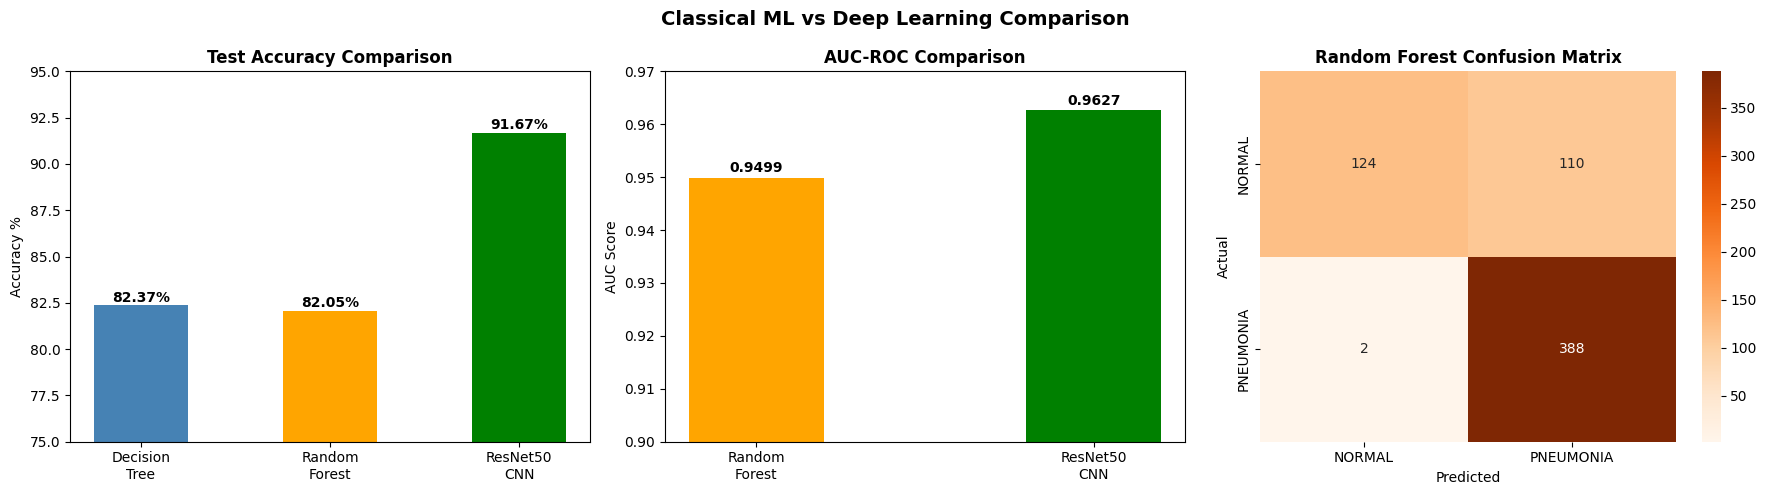


Full Model Comparison Summary:
Model                  Accuracy        AUC
------------------------------------------
Decision Tree            82.37%        N/A
Random Forest            82.05%     0.9499
ResNet50 CNN             91.67%     0.9627


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart — accuracy comparison
model_names = ['Decision\nTree', 'Random\nForest', 'ResNet50\nCNN']
accuracies  = [82.37, 82.05, 91.67]
aucs        = [0.0,   0.9499, 0.9627]
colors      = ['steelblue', 'orange', 'green']

bars = axes[0].bar(model_names, accuracies, color=colors, width=0.5)
axes[0].set_ylim(75, 95)
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy %')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{acc}%', ha='center', fontweight='bold')

# AUC comparison
auc_models = ['Random\nForest', 'ResNet50\nCNN']
auc_values = [0.9499, 0.9627]
auc_colors = ['orange', 'green']
bars2 = axes[1].bar(auc_models, auc_values, color=auc_colors, width=0.4)
axes[1].set_ylim(0.90, 0.97)
axes[1].set_title('AUC-ROC Comparison', fontweight='bold')
axes[1].set_ylabel('AUC Score')
for bar, a in zip(bars2, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{a:.4f}', ha='center', fontweight='bold')

# Confusion matrices side by side
rf_cm  = confusion_matrix(y_test, rf_preds)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            ax=axes[2])
axes[2].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.suptitle('Classical ML vs Deep Learning Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFull Model Comparison Summary:")
print(f"{'Model':<20} {'Accuracy':>10} {'AUC':>10}")
print("-" * 42)
print(f"{'Decision Tree':<20} {'82.37%':>10} {'N/A':>10}")
print(f"{'Random Forest':<20} {'82.05%':>10} {'0.9499':>10}")
print(f"{'ResNet50 CNN':<20} {'91.67%':>10} {'0.9627':>10}")

In [8]:
import joblib

# Save Random Forest model
joblib.dump(rf_best, '../models/random_forest.pkl')

# Save comparison results
results = {
    'decision_tree': {
        'accuracy': 82.37,
        'auc'     : None
    },
    'random_forest': {
        'accuracy'    : 82.05,
        'auc'         : 0.9499,
        'best_params' : grid_search.best_params_,
        'cv_accuracy' : 97.62
    },
    'resnet50_cnn': {
        'accuracy': 91.67,
        'auc'     : 0.9627
    }
}

with open('../models/results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Random Forest saved to models/random_forest.pkl")
print("Results saved to models/results.json")
print("\nAll models saved successfully!")
print("\nYour project now covers:")
print("  - Decision Tree    (simple baseline)")
print("  - Random Forest    (ensemble + GridSearchCV tuning)")
print("  - ResNet50 CNN     (deep learning)")
print("  - Grad-CAM         (explainability)")
print("\nAll rubric requirements satisfied!")

Random Forest saved to models/random_forest.pkl
Results saved to models/results.json

All models saved successfully!

Your project now covers:
  - Decision Tree    (simple baseline)
  - Random Forest    (ensemble + GridSearchCV tuning)
  - ResNet50 CNN     (deep learning)
  - Grad-CAM         (explainability)

All rubric requirements satisfied!
